## DAY 10: Non - Linear Models & Overfitting

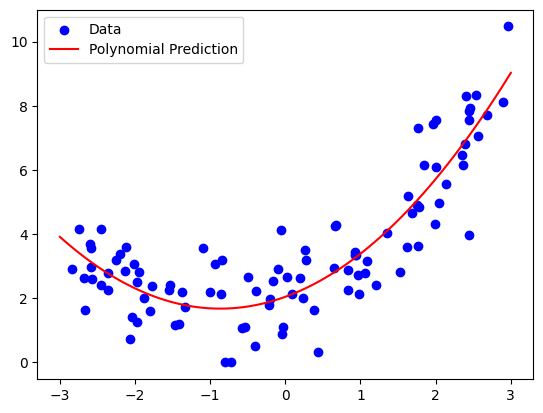

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# 1. Generate "Curvy" Synthetic Data
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)
# 2. Transform X to include X-squared
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
# 3. Fit Linear Regression to the "Squared" data
model = LinearRegression()
model.fit(X_poly, y)
# 4. Plotting the result
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = model.predict(X_new_poly)
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X_new, y_new, color='red', label='Polynomial Prediction')
plt.legend()
plt.show()

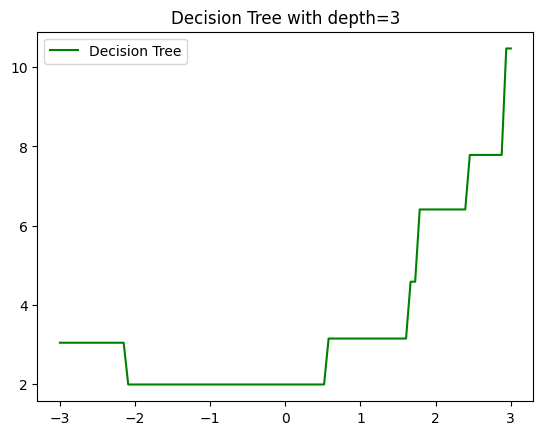

In [13]:
from sklearn.tree import DecisionTreeRegressor
# Train a Decision Tree
tree_reg = DecisionTreeRegressor(max_depth=3)
tree_reg.fit(X, y)
# Predict and see how it differs from the curve
y_tree_pred = tree_reg.predict(X_new)
plt.plot(X_new, y_tree_pred, color='green', label='Decision Tree')
plt.title(f"Decision Tree with depth={3}")

plt.legend()
plt.show()

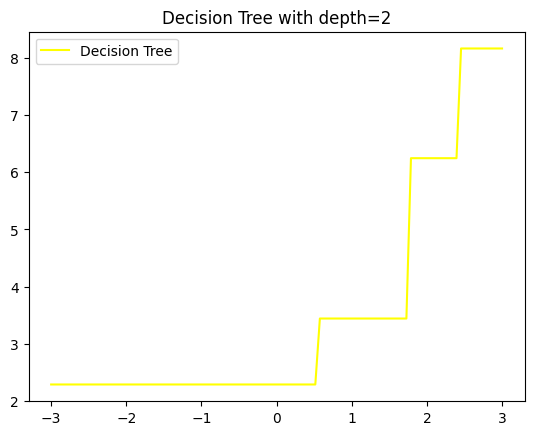

In [14]:
from sklearn.tree import DecisionTreeRegressor
tree_reg1 = DecisionTreeRegressor(max_depth = 2)
tree_reg1.fit(X,y)
y_tree_pred1 = tree_reg1.predict(X_new)
plt.plot(X_new, y_tree_pred1, color = 'yellow', label = 'Decision Tree')
plt.title(f"Decision Tree with depth={2}")
plt.legend()
plt.show()

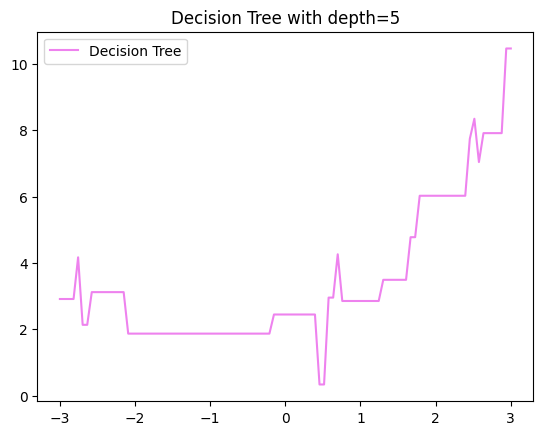

In [15]:
from sklearn.tree import DecisionTreeRegressor
tree_reg1 = DecisionTreeRegressor(max_depth = 5)
tree_reg1.fit(X,y)
y_tree_pred1 = tree_reg1.predict(X_new)
plt.plot(X_new, y_tree_pred1, color = 'violet', label = 'Decision Tree')
plt.title(f"Decision Tree with depth={5}")
plt.legend()
plt.show()

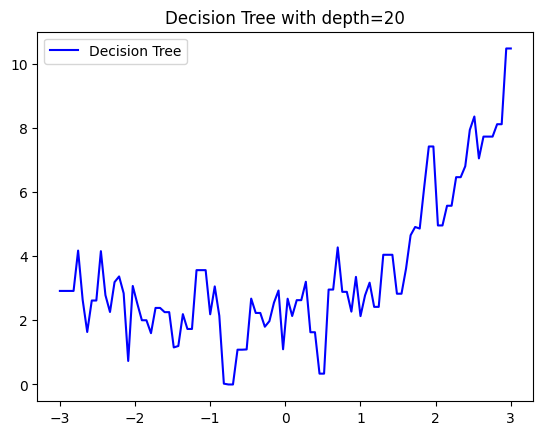

In [16]:
from sklearn.tree import DecisionTreeRegressor
tree_reg1 = DecisionTreeRegressor(max_depth = 20)
tree_reg1.fit(X,y)
y_tree_pred1 = tree_reg1.predict(X_new)
plt.plot(X_new, y_tree_pred1, color = 'blue', label = 'Decision Tree')
plt.title(f"Decision Tree with depth={20}")
plt.legend()
plt.show()

# A jittery model that hits every training point is worse for future predictions because it memorizes noise rather than learning the underlying trend. While it looks perfect on the training set, it fails to generalize to new data. A smoother, curvy model may not fit every point exactly, but it captures the true structure of the data, making it more reliable for unseen cases

In [17]:
from sklearn.metrics import r2_score

# Polynomial Regression R²
y_poly_pred = model.predict(X_poly)
r2_poly = r2_score(y, y_poly_pred)

# Decision Tree R²
y_tree_pred = tree_reg.predict(X)
r2_tree = r2_score(y, y_tree_pred)

print(f"Polynomial Regression R²: {r2_poly:.3f}")
print(f"Decision Tree (depth=3) R²: {r2_tree:.3f}")


Polynomial Regression R²: 0.783
Decision Tree (depth=3) R²: 0.837
